# Tarea 3: Redes convolucionales, modularización y mecanismos de optimización. <br/> CC6204 Deep Learning, Universidad de Chile

**Fecha de entrega: 14 de Octubre de 2026 **

En esta tarea programarás distintos métodos de optimización asi como aplicarlos para redes convolucionales para un problemas de clasificacion mas dificil que los que hemos visto hasta ahora.


IMPORTANTE: A menos que se exprese lo contrario, sólo podrás utilizar las clases y funciones en el módulo [`torch`](https://pytorch.org/docs/stable/torch.html).

(por Luis Cossio, [https://github.com/luisCossio](https://github.com/luisCossio/CC6204-Deep-Learning))

In [8]:
import torch
import torchvision
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Parte 1: Definición de módulos de optimización
Ahora vamos a definir distintos modulos de optimizacion para comprender el comportamiento que estos tienen.  Tome como ejemplo el modelo Stochastic gradient descent.

1. Defina el método SGD con weight decay.
2. Defina el método SGD con momentum.
3. Defina el método RMSProp.


In [14]:
class SGD:
    def __init__(self, parameters, lr=0.01):
        # lo que sea necesario inicializar
        self.parameters = [p for p in parameters if p is not None]
#         self.parameters = (parameters)
        self.lr = lr

    def step(self):
        for parameter in self.parameters:
            parameter.data -= self.lr*(parameter.grad.data)

    def zero_grad(self):
        for parameter in self.parameters:
            if parameter.grad is not None:
                parameter.grad.data.zero_()


## 1a) Método Stochastic Gradient Descent (SGD) con weight decay.

En clases vimos un método muy popular de regularización basado en penalizar el tamaño de los parámetros (no bias) agregando un nuevo término en la función de pérdida. También vimos que una manera alternativa (y posiblemente más fácil de programar) para lograr exactamente el mismo efecto es con el concepto de *weight decay* que en cada paso del descenso de gradiente, "achica un poco" cada parámetro antes de actualizarlo. Para ello defina los parametros de learning rate $\eta=0.01$ y weight decay $\lambda=0.9$.

$$
w' = 1 - \eta \lambda w_t
$$
$$
w_{t+1} = w' - \eta \frac{\partial L}{\partial w}
$$

In [6]:
class SGDWeightDecay:
    def __init__(self, parameters, lr=0.01, weight_decay = 0.9):
        # lo que sea necesario inicializar
        self.parameters = [p for p in parameters if p is not None]
#         self.parameters = (parameters)
        self.lr = lr
    ### CODE HERE ###

    def zero_grad(self):
        for parameter in self.parameters:
            if parameter.grad is not None:
                parameter.grad.data.zero_()


### Observación

Hay muchas formas equivalentes de implementar la regularización por *weight decay* y distintas librerías las implementan de formas alternativas. Es libre de considerar distintas formulaciones matemáticas para esto.

## 1b) Método Stochastic Gradient Descent (SGD) con momentum.

Ahora vamos a implementar una version de SGD con momentum. Para ello hay que mantener una variable de velocidad $v$ para cada peso de una red, y actualizar el valor de actualizacion acordemente:
$$
v_t = \beta v_{t-1} +\frac{\partial L}{\partial \theta}
$$

$$
\theta_t = \theta_{t-1} -  \eta v_t
$$


Considere generar variables de momentos $v$ iguales a 0 para iniciar el proceso de iteracion, y un valor de coeficiente de momentum $\beta=0.9$


In [4]:
class SGDMomentum:
    def __init__(self, parameters, lr, momentum=0.9):
        # lo que sea necesario inicializar
        self.parameters = [p for p in parameters if p is not None]

### CODE HERE ###

    def zero_grad(self):
        for parameter in self.parameters:
            if parameter.grad is not None:
                parameter.grad.data.zero_()


## 1c) RMSProp

En esta parte implementarás el algoritmo de RMSProp (Root Mean Square Propagation) que mantiene un promedio móvil exponencial de los cuadrados de los gradientes calculados hasta el momento y modifica las tasas de aprendizaje para cada parámetro dependiendo de ese promedio. En específico, RMSProp usa la siguiente regla de actualización para cada conjunto de parámetros $\theta$:
<br>

\begin{eqnarray*}
S_{\partial \theta} & := & \beta S_{\partial \theta} + (1-\beta)\left(\frac{\partial \mathcal{L}}{\partial \theta}*\frac{\partial \mathcal{L}}{\partial \theta}\right) \\
\theta & := & \theta - \eta\frac{1}{\sqrt{S_{\partial \theta} }+ \epsilon}*\frac{\partial \mathcal{L}}{\partial \theta  }
\end{eqnarray*}
<br>

donde $S_{\partial \theta}$ es un tensor de las mismas dimensiones de $\theta$ y se inicializa como $0$ antes de emepzar el entrenamiento.
La operación $*$ representa a una multiplicación punto a punto.

Implementa una nueva clase `RMSProp` que implemente este optimizador. El inicializador debiera tener dos parámetros: `lr` para la tasa de aprendizaje ($\eta$ en las fórmulas de arriba) y `beta` para el multiplicador del promedio. Asinga los valores por defecto `lr=0.001` y `beta=0.9`. Agrega un parámetro adicional `epsilon` con valor por defecto $10^{-8}$, y úsalo para evitar la división por $0$ sumándolo al denominador en la fórmula con la raiz cuadrada.

In [5]:
class RMSProp():
    def __init__(self, parameters, lr=0.001, beta=0.9, epsilon=1e-8):
        # en este caso debes inicializar la variable que acumula
        # el promedio exponencial de los cuadrados
        self.parameters = [p for p in parameters if p is not None]
### CODE HERE ###

    def zero_grad(self):
        for parameter in self.parameters:
            if parameter.grad is not None:
                parameter.grad.data.zero_()

# Parte 2: Evaluacion de optimizadores
En la siguiente parte se va a evaluar una red sencilla de múltiples capas para tratar de resolver un problema unidimensional de predicción de polinomios de grado 4. La idea es generar una red que pueda predecir el comportamiento de  una función polinomial usando capas feed forward. Adicionalmente se va a usar una base de datos que genera esta distribución y agrega ruido en los datos. Observe la curva en un caso con ruido igual a 0.
1. Compare los distintos métodos de optimización con ruido igual 0.05
2. Utilice el módulo optim.Adam para entrenar el modelo y comparar con los resultados obtenidos con sus optimizadores.
3. Escoja el mejor método y evalúe el comportamiento de la optimización variando el batch-size.
4. Grafique las predicciones del modelo final, y compare con los resultados del dataset sin ruido.
5. ¿Cuál fue el peor optimizador? De una justificación.


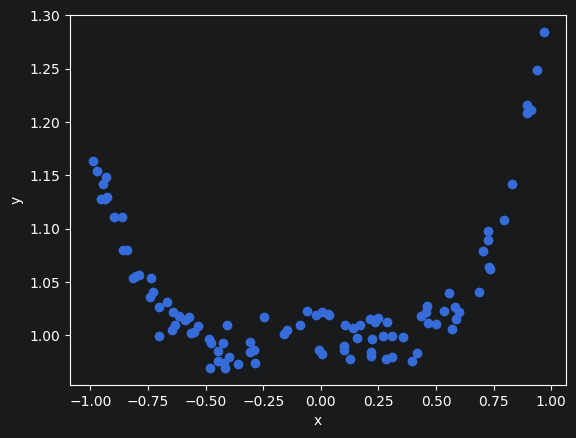

In [42]:

class DatasetPolynomial(Dataset):
    def __init__(self, params_function:list = [0.333,0.066666,-0.075,0,1], noise_level=0.2,size_dataset =100):
        self.noise_level = noise_level
        self.size_dataset = size_dataset
        self.params_function = params_function

    def __len__(self):
        return self.size_dataset

    def __getitem__(self, item):
        x = (torch.rand([1]) - 0.5) *  2
        y = 0
        for i,coef in enumerate(self.params_function[:-1]):
            y += coef * x ** (len(self.params_function)-1-i)
        y += self.params_function[-1]
        y += ((torch.rand([1])- 0.5) * (self.noise_level))
        return x, y

n = 100
data = DatasetPolynomial(size_dataset=n,noise_level=0.05)

samples = torch.empty([n,2])
for i in range(len(data)):
    x,y = data[i]
    samples[i,0] = x[0]
    samples[i,1] = y[0]

plt.scatter(samples[:,0],samples[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [43]:
batch_size = 8
train_loader = DataLoader(data, batch_size=batch_size, shuffle=False)

In [44]:
class FeedForwardNet(nn.Module):
    """Basic feedforward network: 2 hidden layers with ReLU activation."""

    def __init__(self, input_features=24, hidden_features=[32,128], output_features=1):
        super().__init__()
        self.layer_1 = nn.Linear(input_features, hidden_features[0])
        self.layer_2 = nn.Linear(hidden_features[0], hidden_features[1])
        self.layer_out = nn.Linear(hidden_features[1], output_features)

    def forward(self, x):
        h = F.relu(self.layer_1(x))
        h = F.relu(self.layer_2(h))
        return self.layer_out(h)



In [49]:
criterion = nn.MSELoss()

model = FeedForwardNet(1)
train_losses = []
epochs = 20
optimizer = RMSProp(model.parameters())
for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        # the dataset yields (batch, 1, features), drop the extra axis

        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    train_losses += [running_loss / len(train_loader)]

100%|██████████| 20/20 [00:01<00:00, 15.03it/s]


In [50]:
# train_losses_sgd = train_losses
# train_losses_sgdw = train_losses
# train_losses_sgdm = train_losses
# train_losses_sgdr = train_losses
# train_losses_adam = train_losses


Text(0.5, 0, 'Loss')

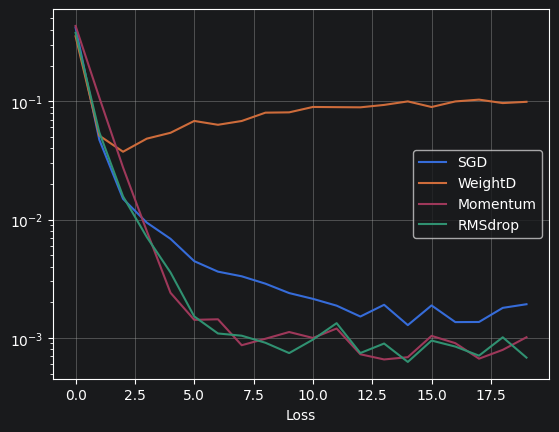

In [52]:
plt.plot(torch.arange(epochs), train_losses_sgd,label="SGD")
plt.plot(torch.arange(epochs), train_losses_sgdw,label="WeightD")
plt.plot(torch.arange(epochs), train_losses_sgdm,label="Momentum")
plt.plot(torch.arange(epochs), train_losses_sgdr,label="RMSdrop")
plt.plot(torch.arange(epochs), train_losses_adam,label="Adam")

# plt.xscale('log')  # Logarithmic x-axis
plt.yscale('log')  # Logarithmic y-axis
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')

# Parte 3: Exploración de datos.
Ahora vamos a explorar la base de datos CIFAR10. Es una base de datos que consta de 10 clases de objetos de distinta naturaleza, en imágenes recortadas de tamaño 32 x 32.
1. Defina una función que muestre 4 imágenes aleatorias.
2. Describir la distribución de las clases en el conjunto de test.
3. ¿Qué es lo que hace el objeto “transform”?



In [10]:


# 1. Define transformations (convert to tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Load the dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
sample,label = train_dataset[0]
print(sample.size())
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 3. Create DataLoaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

torch.Size([3, 32, 32])


In [ ]:
def plot_images(dataset):
    ### CODE HERE ###


# Parte 4: Generación de una red.
1. Defina una red convolucional con los siguientes componentes:
- Capas convolucionales
- Normalización
- Funcion de activacion
- Global Average pooling

```Considere que la salida son logits (rango [-inf,inf])  no probabilidades. ```


2. Defina una segunda red que agregue Dropout.
3. Defina una tercera red que agregue skip connections.


In [11]:
class CNN(nn.Module):
  def __init__(self):
        ### CODE HERE ###


# Parte 5: Entrenamiento de una red.
Usa tu red neuronal para entrenar con los datos de CIFAR10 usando el algoritmo de optimización que mejores resultados entregaron.
1. Entrene cada modelo con algún optimizador a su elección.
2. Evalúe la matriz de confusión para el mejor modelo.
3. Evalúe otro algoritmo de optimización en el mejor modelo.


In [12]:
def train(network: nn.Module, optimizer: nn.Module,  epoch:int,criterion:nn.Module, train_loader: DataLoader, train_losses:list):
    network.train() #Modo
    train_loss = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    network.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    for batchId, (data, target) in enumerate(train_loader): #Iterate over batches
        data = data.to(device)
        target = target.to(device)

        #Feedforward pass
        optimizer.zero_grad()
        output = network(data)
        # prob = output.softmax(dim=1)
        log_prob = output.log_softmax(dim=1)

        loss = criterion(log_prob, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    length = len(train_loader.dataset)
    train_loss /= length
    train_losses += [train_loss]


#Testing
def test(network: nn.Module, test_loader:DataLoader,criterion:nn.Module, test_losses:list):
    network.eval() #Test mode
    test_loss = 0
    correct = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            output = network(data)
            # prob = output.softmax(dim=1)
            log_prob = output.log_softmax(dim=1)

            loss = criterion(log_prob, target)
            test_loss += loss.item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
    length = len(test_loader.dataset)
    test_loss /= length
    test_losses.append(test_loss)



In [ ]:

network = CNN()
optimizer = SGD(network.parameters())
# Train the model
num_epochs = 20
log_interval = 10
accuracy_epochs = []

train_losses = []
train_counter = []
test_losses = []
criterion = nn.CrossEntropyLoss()
for epoch in tqdm(range(num_epochs)):
    train(network, optimizer, epoch,criterion, train_loader,train_losses)
    test(network,test_loader,criterion,test_losses)
    train_counter += [epoch]
    if epoch % log_interval==0:
        print('Train epoch: {}  Loss train: {:.6f} loss test  {:.6f}'.format(epoch,  test_losses[-1], test_losses[-1]))
        torch.save(network.state_dict(),'model_{:d}.pth'.format(epoch))


  5%|▌         | 1/20 [00:08<02:44,  8.67s/it]

Train epoch: 0  Loss train: 0.065080 loss test  0.065080


 40%|████      | 8/20 [00:49<01:12,  6.03s/it]

# Parte 6: Análisis
1. Comente su elección de optimizador.
2. ¿Hubo diferencias notorias entre modelos de redes? Comente.
3. Noto algún patrón relevante en la matriz de confusión?
4. ¿Cómo afecta el algoritmo de optimización al tiempo de convergencia de la red para los datos de entrenamiento?